<a href="https://colab.research.google.com/github/MarwanHossain/basic-insurance-Data-Analysis/blob/main/insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# we dicussed on this data set on https://chatgpt.com/c/6a3d428a-5b78-83ee-bdf8-d67162035c7e?mweb_fallback=1

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

In [4]:
#basic info
df= pd.read_csv("/content/drive/MyDrive/DS332_Dataset/DOC-20260617-WA0000.csv", sep=";",decimal=",")
print(df.head())
print(" ")
print(df.tail())
print(" ")
print(df.info())
print(" ")
print(f"Rows: {df.shape[0]}, columns:{df.shape[1]}")

    age     sex     bmi  children smoker     region   charges
0  19.0  female  27.900         0    yes  southwest  16884.92
1  18.0    male  33.770         1     no  southeast   1725.55
2  28.0    male  33.000         3     no  southeast   4449.46
3  33.0    male  22.705         0     no  northwest  21984.47
4  32.0    male  28.880         0     no  northwest   3866.86
 
     age        sex     bmi  children smoker     region   charges
26  63.0     female  23.085         0     no  northwest  14451.84
27  55.0  northwest  32.775         2     no  northwest  12268.63
28  23.0       male  17.385         1     no  northwest   2775.19
29  31.0       male  36.300         2    yes  southwest  38711.00
30   NaN        NaN  36.300         2    yes  southwest  38711.00
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       30 non-null     float64
 1   sex 

In [5]:
#Null value finding
print(df.isnull())
print(df.isnull().sum())

      age    sex    bmi  children  smoker  region  charges
0   False  False  False     False   False   False    False
1   False  False  False     False   False   False    False
2   False  False  False     False   False   False    False
3   False  False  False     False   False   False    False
4   False  False  False     False   False   False    False
5   False  False  False     False   False   False    False
6   False  False  False     False   False   False    False
7   False  False  False     False   False   False    False
8   False  False  False     False   False   False    False
9   False  False  False     False   False   False    False
10  False  False  False     False   False   False    False
11  False  False  False     False   False   False    False
12  False  False  False     False   False   False    False
13  False  False  False     False   False   False    False
14  False  False  False     False   False   False    False
15  False  False  False     False   False   False    Fal

In [6]:
df["age"]=df["age"].fillna(df["age"].median())
df['sex'] = df['sex'].fillna(df['sex'].mode()[0])
df['bmi'] = df['bmi'].fillna(df['bmi'].median())
print(df.isnull().sum())
print(df.duplicated().sum())
print("\n--- 2.3 Handling Outliers (IQR Capping on BMI) ---")
Q1= df["bmi"].quantile(.25)
Q3= df["bmi"].quantile(.75)
IQR= Q3-Q1
lower_bound=Q1-(1.5*IQR)
upper_bound=Q3+(1.5*IQR)



age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
0

--- 2.3 Handling Outliers (IQR Capping on BMI) ---


In [7]:
# Cap outliers to the upper/lower bounds
df["bmi"]=np.where(df["bmi"]>upper_bound,upper_bound,df["bmi"])
df["bmi"]=np.where(df["bmi"]<lower_bound,lower_bound,df["bmi"])

In [8]:
# ==========================================
# 3. CATEGORICAL ENCODING
# ==========================================

encode_sex= LabelEncoder()
encode_smoker= LabelEncoder()
encode_region=LabelEncoder()

df["sex"]= encode_sex.fit_transform(df["sex"].astype(str))
df["smoker"]= encode_smoker.fit_transform(df["smoker"].astype(str))
df["region"]= encode_region.fit_transform(df["region"].astype(str))

print(df[["sex","smoker","region"]].head())
df.head()


   sex  smoker  region
0    0       1       3
1    1       0       2
2    1       0       2
3    1       0       1
4    1       0       1


,age,sex,bmi,children,smoker,region,charges
0,19.0,0,27.900,0,1,3,16884.92
1,18.0,1,33.770,1,0,2,1725.55
2,28.0,1,33.000,3,0,2,4449.46
3,33.0,1,22.705,0,0,1,21984.47
4,32.0,1,28.880,0,0,1,3866.86


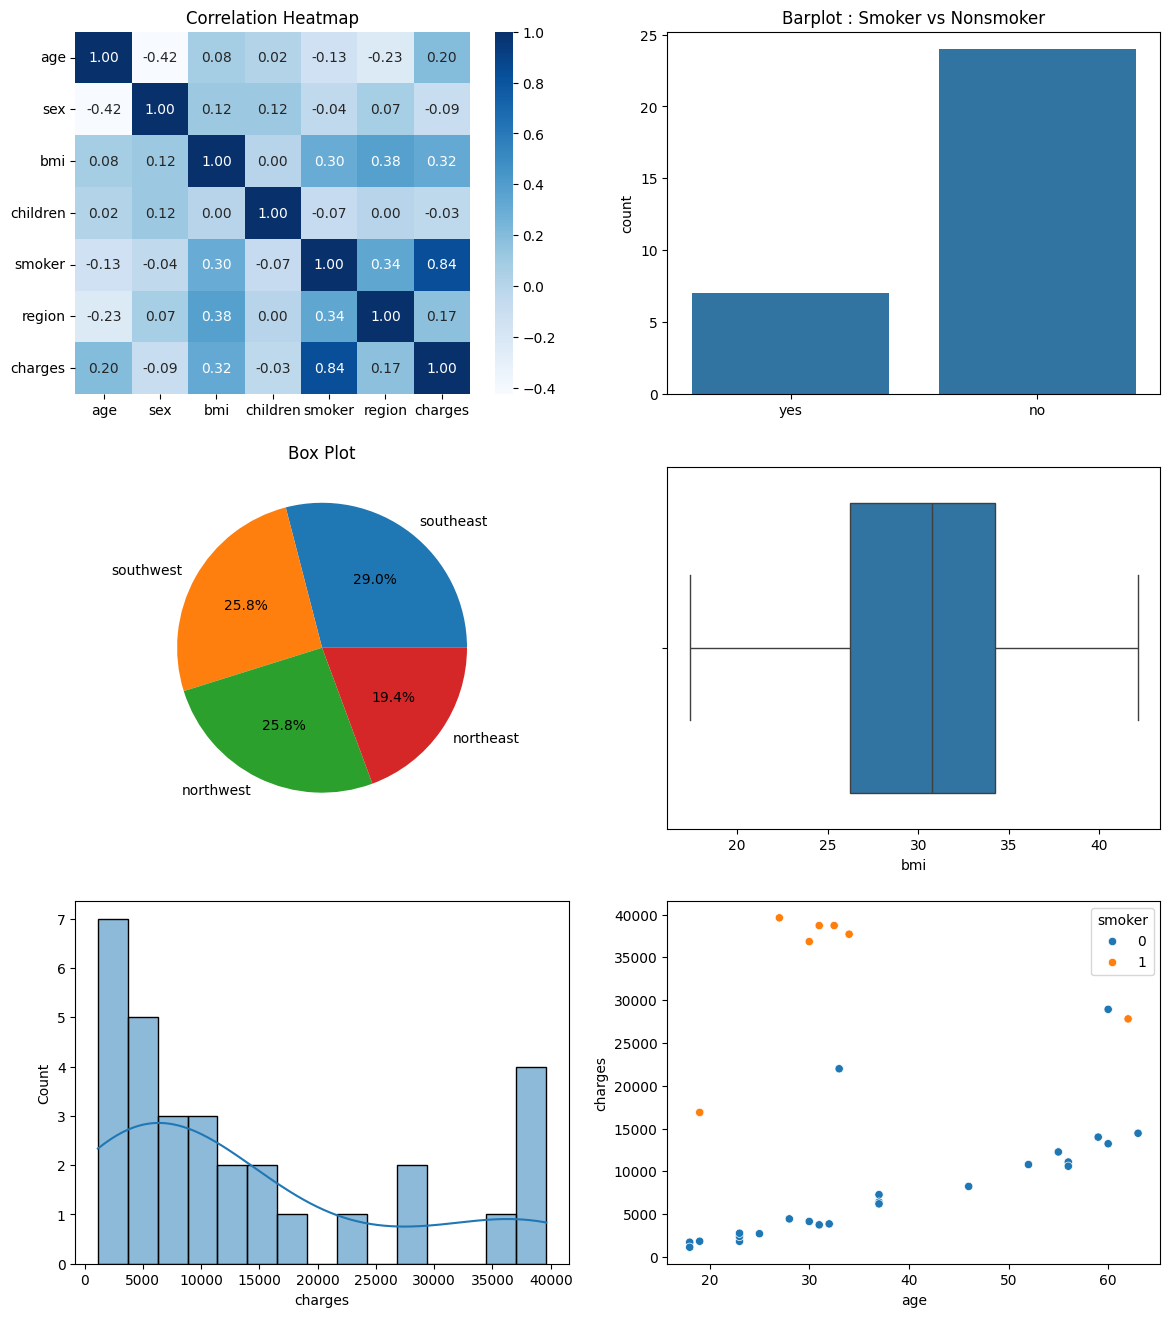

In [9]:
# Data Visualization
#======================
fig, axes= plt.subplots(3,2 ,figsize=(14,16))

# Heatmap (Correlation Matrix)
sns.heatmap(df.corr(), annot=True, cmap="Blues",fmt=".2f",ax=axes[0,0])
axes[0, 0].set_title('Correlation Heatmap')

#barchart
sns.countplot(
    x=encode_smoker.inverse_transform(df["smoker"]),ax=axes[0,1]
)
axes[0,1].set_title("Barplot : Smoker vs Nonsmoker")

#pie chart
region_counts= df["region"].value_counts()
axes[1,0].pie(region_counts, labels= encode_region.inverse_transform(region_counts.index),autopct='%1.1f%%')
autopct='%1.1f%%'
axes[1,0].set_title("pie chart")

#Boxplot
sns.boxplot(x=df["bmi"], ax=axes[1,1])
axes[1,0].set_title("Box Plot")

#Histogram
sns.histplot(df["charges"],ax=axes[2,0],bins=15, kde=True)

#scatter plot
sns.scatterplot(data=df, x="age", y="charges", hue="smoker")

plt.show()

In [10]:
#Liner regression Model

#Single Linear Regression (Using 'age')
Y= df["charges"]

X_single= df[["age"]]

X_train_s, X_test_s, Y_train_s, Y_test_s= train_test_split(X_single,Y, test_size=.20, random_state=42)

single_model= LinearRegression()
single_model.fit(X_train_s,Y_train_s)

# print(single_model.coef_)
# print(single_model.intercept_)

Y_predict_s= single_model.predict(X_test_s)
# print(Y_predict_s)
print(f"r^2 value: {r2_score(Y_test_s,Y_predict_s)}")
print(f"mean absolute error: {mean_absolute_error(Y_test_s,Y_predict_s)}")



r^2 value: -0.07712797032053587
mean absolute error: 13027.802823402515


In [11]:
#Multiple Linear Regression (Using all features)
X_multi= df.drop(columns=["charges"])
X_train_m, X_test_m, Y_train_m, Y_test_m= train_test_split(X_multi,Y, test_size=.20, random_state=42)


scaler = StandardScaler()
X_train_m_scaled= scaler.fit_transform(X_train_m)
X_test_m_scaled= scaler.transform(X_test_m)

multi_model = LinearRegression()
multi_model.fit(X_train_m_scaled, Y_train_m)
Y_pred_m = multi_model.predict(X_test_m_scaled)

print(f"Multiple LR R2 Score (Accuracy): {r2_score(Y_test_m, Y_pred_m):.4f}")
print(f"Multiple LR Mean Absolute Error: {mean_absolute_error(Y_test_m, Y_pred_m):.2f}")



Multiple LR R2 Score (Accuracy): 0.6720
Multiple LR Mean Absolute Error: 6809.92


In [12]:
# Model Save
joblib.dump(multi_model, 'insurance_lr_model.pkl')
joblib.dump(scaler, 'insurance_scaler.pkl')

['insurance_scaler.pkl']

In [13]:
#Load the save model and scaler
try:
  loaded_model= joblib.load('insurance_lr_model.pkl')
  loaded_scaler= joblib.load('insurance_scaler.pkl')
except FileNotFoundError:
  print("Error: Please make sure 'insurance_lr_model.pkl' and 'insurance_scaler.pkl' are uploaded to your Colab files panel.")


In [14]:
#DEFINE NEW VARIABLE DATA

new_customers = pd.DataFrame([
    {
        'age': 25,
        'sex': 1,       # male
        'bmi': 24.2,    # Normal BMI
        'children': 0,
        'smoker': 0,    # Non-smoker
        'region': 3     # southwest
    },
    {
        'age': 45,
        'sex': 0,       # female
        'bmi': 36.5,    # High BMI (Obese range)
        'children': 2,
        'smoker': 1,    # Smoker
        'region': 2     # southeast
    },
    {
        'age': 62,
        'sex': 0,       # female
        'bmi': 28.1,    # Overweight BMI
        'children': 1,
        'smoker': 0,    # Non-smoker
        'region': 1     # northwest
    }
])

print("New customer input profiles:")
print(new_customers)

New customer input profiles:
   age  sex   bmi  children  smoker  region
0   25    1  24.2         0       0       3
1   45    0  36.5         2       1       2
2   62    0  28.1         1       0       1


In [15]:
#PREPROCESS & SCALE NEW DATA
#___________________________#
# Multiple Linear Regression relies heavily on the exact scale established during training.
# We use .transform() instead of .fit_transform() so we don't recalculate the weights.

new_customer_scaled= loaded_scaler.transform(new_customers)


In [18]:
#PREDICT USING THE LOADED MODEL

predicted_charges= loaded_model.predict(new_customer_scaled)
new_customers["predicted_charges"]= np.round(predicted_charges,2)

print(new_customers)


   age  sex   bmi  children  smoker  region  predicted_charges
0   25    1  24.2         0       0       3            2951.48
1   45    0  36.5         2       1       2           34189.55
2   62    0  28.1         1       0       1           12323.76
